# SOB4ES - Modelo XGBoost
### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluacion de los modelos

Este notebook recorre el ciclo de vida completo del modelo de inteligencia artificial.

**Datasets utilizados:**
- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por pais)
- `test.csv`  - Busqueda de hiperparametros y validacion cruzada (15 %)
- `eval.csv`  - Evaluacion final e imparcial del rendimiento (15 %)

**Estructura del notebook:**
1. **Configuracion:** Importaciones y parametros globales.
2. **Carga de datos:** Se cargan los tres splits pre-generados.
3. **Tuning:** Busqueda aleatoria de la mejor combinacion de hiperparametros.
4. **Validacion cruzada:** Evaluacion de robustez mediante repeticion de pliegues.
5. **Explicabilidad (SHAP):** Analisis de importancia de variables.
6. **Produccion:** Entrenamiento del ensamble final y exportacion de modelos.
7. **Evaluacion final:** Medicion del rendimiento real sobre `eval.csv`.

---
## 1.- Configuracion del entorno
Importaciones y configuracion de rutas y variables globales.

In [19]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt

import shap
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_validate, KFold

# ignoramos los warnings
warnings.filterwarnings('ignore')
#os.environ["PYTHONWARNINGS"] = "ignore"

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/XGBoost'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

TARGETS = [
    'nematode_shannon_z', 'macro_shannon_z', 'earthworm_shannon_z', 'orib_shannon_z',
    'meso_shannon_z', 'coll_shannon_z', 'bac_shannon_z', 'fun_shannon_z',
    'euk_shannon_z', 'oomy_shannon_z', 'cerc_shannon_z'
]

FEATURES_AUTORIZADAS = [
    'total_plant_cover_z', 'clay_content_z', 'silt_content_z', 'sand_content_z',
    'aggregate_stability_z', 'bulk_density_z', 'soil_moisture_z', 'as_z', 'cu_z',
    'k_z', 'mo_z', 'ni_z', 'p_z', 'pb_z', 'zn_z', 'soil_ph_z',
    'plot_total_organic_c_z', 'plot_total_n_z', 'fun_total_reads_z',
    'oomy_total_reads_z', 'cerc_total_reads_z', 'gee_temp_media_C_z', 'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z', 'dem_elevacion_m_z', 'dem_pendiente_deg_z', 'dem_orientacion_deg_z',
    'eu_clay_content_z', 'eu_sand_content_z', 'eu_silt_content_z', 'eu_water_holding_capacity_z',
    'eu_cn_ratio_z', 'eu_p_z', 'eu_ph_z', 'eu_as_z', 'eu_organic_carbon_octop_z', 'eu_zn_z'
]

print('Librerias y variables cargadas.')

Librerias y variables cargadas.


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la division 70/15/15 estratificada por pais.

| Archivo    | Uso                                      | Filas aprox. |
|------------|------------------------------------------|--------------|
| `train.csv`| Ajuste del modelo                        | 299          |
| `test.csv` | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv` | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la seccion 7 para garantizar una estimacion imparcial del rendimiento.

In [20]:
def cargar_csv(ruta, nombre):
    """Carga un CSV (sep=',' o ';') y valida las columnas necesarias."""
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontro el archivo: {ruta}")
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f"  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")
    return df

print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados.")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados.
X_train: (299, 37)  |  X_test: (64, 37)  |  X_eval: (65, 37)


## 3.- Busqueda de hiperparametros (Tuning)

Se realiza una busqueda aleatoria (`RandomizedSearchCV`) sobre el espacio de hiperparametros del modelo XGBoost. La busqueda se ejecuta exclusivamente sobre `X_train` para evitar cualquier fuga de informacion hacia los splits de validacion y evaluacion.

Como variable objetivo de referencia se usa `earthworm_shannon_z` (lombrices de tierra).

In [21]:
print("Iniciando busqueda de hiperparametros (Tuning)...")
print("Este proceso puede tardar varios minutos.\n")

param_grid_exhaustivo = {
    'n_estimators': [100, 300, 500, 800, 1000],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5, 1.0],
    'min_child_weight': [1, 3, 5, 7]
}

y_prueba = y_train['earthworm_shannon_z'].values

buscador_exhaustivo = RandomizedSearchCV(
    estimator=XGBRegressor(tree_method='hist', random_state=42),
    param_distributions=param_grid_exhaustivo,
    n_iter=50,
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

import time
start_tune = time.time()
buscador_exhaustivo.fit(X_train, y_prueba)

print(f"\nBusqueda completada en {(time.time() - start_tune)/60:.1f} minutos.")
print(f"Mejor R2 obtenido: {buscador_exhaustivo.best_score_:.4f}")
print(f"Hiperparametros optimos: {buscador_exhaustivo.best_params_}")

XGB_OPTIMAL_PARAMS = buscador_exhaustivo.best_params_
XGB_OPTIMAL_PARAMS['tree_method'] = 'hist'
XGB_OPTIMAL_PARAMS['random_state'] = 42

Iniciando busqueda de hiperparametros (Tuning)...
Este proceso puede tardar varios minutos.

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Busqueda completada en 0.8 minutos.
Mejor R2 obtenido: 0.4890
Hiperparametros optimos: {'subsample': 0.7, 'n_estimators': 1000, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.6}


## 4.- Validacion cruzada

Se evalua la robustez del modelo mediante validacion cruzada repetida (5 pliegues x 3 repeticiones = 15 evaluaciones) aplicada sobre `X_train`. Esto permite detectar sobreajuste comparando el rendimiento en entrenamiento y en los pliegues de validacion.

In [22]:
from sklearn.model_selection import RepeatedKFold

print("Validacion cruzada repetida (15 evaluaciones sobre X_train)...\n")

modelo_evaluacion    = XGBRegressor(**XGB_OPTIMAL_PARAMS)
cortador_implacable  = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
metricas             = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

resultados_examen = cross_validate(
    estimator=modelo_evaluacion,
    X=X_train,
    y=y_train['earthworm_shannon_z'].values,
    cv=cortador_implacable,
    scoring=metricas,
    return_train_score=True
)

r2_entrenamiento = np.mean(resultados_examen['train_r2'])
r2_examen_real   = np.mean(resultados_examen['test_r2'])
r2_desviacion    = np.std(resultados_examen['test_r2'])
rmse_real        = np.mean(-resultados_examen['test_neg_root_mean_squared_error'])
mae_real         = np.mean(-resultados_examen['test_neg_mean_absolute_error'])

print("Resultados (promedio de 15 evaluaciones):")
print(f"  Train R2          : {r2_entrenamiento:.4f}")
print(f"  Validacion R2 (CV): {r2_examen_real:.4f} +/- {r2_desviacion:.4f}")
print(f"  RMSE              : {rmse_real:.4f} puntos de Shannon H'")
print(f"  MAE               : {mae_real:.4f} puntos de Shannon H'")

diferencia = r2_entrenamiento - r2_examen_real
if diferencia > 0.15:
    print(f"\nAviso: diferencia train/validacion = {diferencia:.4f}. Posible sobreajuste.")
else:
    print(f"\nDiferencia train/validacion = {diferencia:.4f}. El modelo generaliza correctamente.")

Validacion cruzada repetida (15 evaluaciones sobre X_train)...

Resultados (promedio de 15 evaluaciones):
  Train R2          : 0.9266
  Validacion R2 (CV): 0.4854 +/- 0.1055
  RMSE              : 0.6914 puntos de Shannon H'
  MAE               : 0.4983 puntos de Shannon H'

Aviso: diferencia train/validacion = 0.4412. Posible sobreajuste.


## 5.- Explicabilidad del modelo (SHAP)

Se utiliza SHAP (SHapley Additive exPlanations) para identificar que variables influyen mas en las predicciones del modelo y en que direccion lo hacen.

El grafico de puntos muestra las 10 variables mas importantes:
- Las variables se ordenan de mayor a menor importancia global (de arriba a abajo).
- El color indica el valor de la variable (rojo = valor alto, azul = valor bajo).
- La posicion horizontal indica el efecto sobre la prediccion (derecha = aumenta el indice, izquierda = lo reduce).

Calculando valores SHAP sobre X_train...
Top 10 variables por importancia SHAP (earthworm_shannon_z):


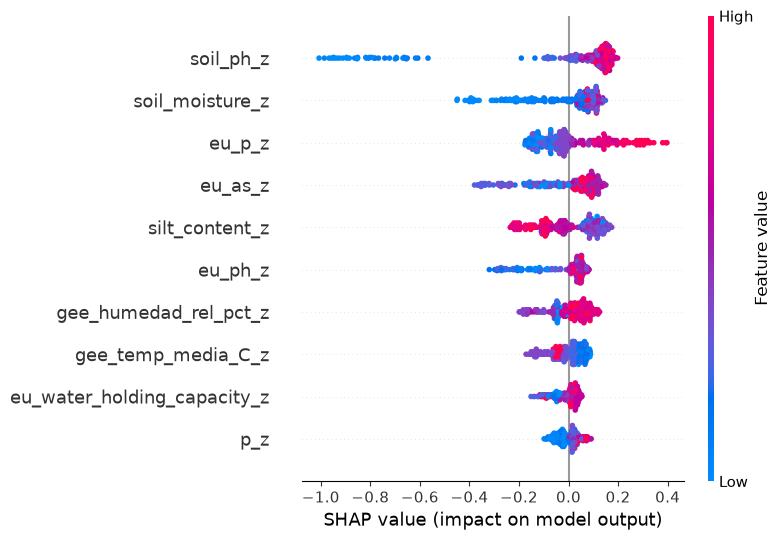

In [23]:
%matplotlib inline

print("Calculando valores SHAP sobre X_train...")

modelo_explicable = XGBRegressor(**XGB_OPTIMAL_PARAMS)
modelo_explicable.fit(X_train, y_train['earthworm_shannon_z'].values)

explainer   = shap.TreeExplainer(modelo_explicable)
shap_values = explainer.shap_values(X_train)

print("Top 10 variables por importancia SHAP (earthworm_shannon_z):")
shap.summary_plot(shap_values, X_train, plot_type="dot", max_display=10)

## 6.- Entrenamiento de produccion

Se entrena un ensamble de 5 modelos por cada variable objetivo, variando la semilla aleatoria en cada uno. Esto reduce la varianza de las predicciones y mejora la robustez en produccion.

Todos los modelos se entrenan sobre `X_train` y se guardan en disco en formato `.pkl`.

In [24]:
print("Entrenamiento de produccion (ensamble de 5 modelos por target)...")
print("-" * 70)

global_start_time = time.time()
NUM_EXPERTOS = 5

for idx, target_col in enumerate(TARGETS, 1):
    target_start_time = time.time()
    y = y_train[target_col].values

    for experto_id in range(NUM_EXPERTOS):
        parametros_experto = XGB_OPTIMAL_PARAMS.copy()
        parametros_experto['random_state'] = 42 + experto_id

        model = XGBRegressor(**parametros_experto)
        model.fit(X_train, y)

        pkl_path = os.path.join(MODELS_DIR, f"xgb_prod_{target_col}_exp{experto_id}.pkl")
        joblib.dump(model, pkl_path)

    elapsed = time.time() - target_start_time
    print(f"  [{idx}/{len(TARGETS)}] {target_col:30} completado ({elapsed:.1f}s)")

print("-" * 70)
print(f"Produccion completada en {(time.time() - global_start_time)/60:.1f} minutos.")
print(f"Modelos guardados: {len(TARGETS) * NUM_EXPERTOS} ({NUM_EXPERTOS} por target).")

Entrenamiento de produccion (ensamble de 5 modelos por target)...
----------------------------------------------------------------------
  [1/11] nematode_shannon_z             completado (4.7s)
  [2/11] macro_shannon_z                completado (4.8s)
  [3/11] earthworm_shannon_z            completado (4.2s)
  [4/11] orib_shannon_z                 completado (4.7s)
  [5/11] meso_shannon_z                 completado (4.6s)
  [6/11] coll_shannon_z                 completado (4.6s)
  [7/11] bac_shannon_z                  completado (5.3s)
  [8/11] fun_shannon_z                  completado (4.9s)
  [9/11] euk_shannon_z                  completado (4.5s)
  [10/11] oomy_shannon_z                 completado (4.6s)
  [11/11] cerc_shannon_z                 completado (4.9s)
----------------------------------------------------------------------
Produccion completada en 0.9 minutos.
Modelos guardados: 55 (5 por target).


## 7.- Evaluacion final sobre eval.csv

Por primera vez se usa `eval.csv`: el dataset que el modelo no ha visto en ningun momento anterior. Esto proporciona una estimacion real e imparcial del rendimiento en produccion.

Ademas se ejecuta una comprobacion de funcionamiento completo del pipeline (smoke test): se carga el ensamble desde disco, se predice sobre datos nuevos y se verifica que la inferencia por consenso funciona correctamente.

**Interpretacion del indice Shannon H':**  
El modelo predice el indice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica). Un valor bajo indica un suelo poco diverso; un valor alto, un suelo biologicamente rico.

In [25]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

test_target  = 'earthworm_shannon_z'
NUM_EXPERTOS = 5


# Evaluacion final
# Usamos eval.csv, que el modelo no ha visto hasta ahora.
# Esto nos da una medida real de como funcionara con datos nuevos en produccion.

print('Evaluacion final sobre eval.csv')
print('-' * 50)

# Cargamos cada uno de los 5 modelos XGBoost guardados y les pedimos que predigan
# la diversidad de lombrices para todas las parcelas de eval.csv.
preds_eval = []
for experto_id in range(NUM_EXPERTOS):
    ruta  = os.path.join(MODELS_DIR, f'xgb_prod_{test_target}_exp{experto_id}.pkl')
    model = joblib.load(ruta)
    preds_eval.append(model.predict(X_eval))

# Promediamos las predicciones de los 5 modelos para obtener
# una estimacion mas estable (menos influenciada por la aleatoriedad de cada modelo).
y_pred_eval = np.mean(preds_eval, axis=0)
y_true_eval = y_eval[test_target].values

print(f'  R2   : {r2_score(y_true_eval, y_pred_eval):.4f}')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_true_eval, y_pred_eval)):.4f} puntos de Shannon H\'')
print(f'  MAE  : {mean_absolute_error(y_true_eval, y_pred_eval):.4f} puntos de Shannon H\'')


# Prueba de funcionamiento (smoke test)
# Usamos 3 filas reales de eval.csv para comprobar que el pipeline funciona
# y que las predicciones son coherentes con los valores reales observados.

print('\nSmoke test - Inferencia con datos reales')
print('-' * 65)

try:
    # Tomamos 3 filas reales al azar del dataset de evaluacion.
    df_new_data      = X_eval.sample(n=3) # establecer random_state si quieres que sea constante
    indices_elegidos = df_new_data.index
    valores_reales   = y_eval.loc[indices_elegidos, test_target].values

    # Cada uno de los 5 modelos vota con su propia prediccion para las 3 parcelas.
    votos = []
    for experto_id in range(NUM_EXPERTOS):
        ruta  = os.path.join(MODELS_DIR, f'xgb_prod_{test_target}_exp{experto_id}.pkl')
        m     = joblib.load(ruta)
        pred  = m.predict(df_new_data)
        votos.append(pred)
        print(f'  Modelo {experto_id+1} \n '
              f'\tFila {indices_elegidos[0]}: {pred[0]:.4f}\t'
              f'\tFila {indices_elegidos[1]}: {pred[1]:.4f}\t'
              f'\tFila {indices_elegidos[2]}: {pred[2]:.4f}')
    print('')

    # Promediamos los 5 votos para obtener la prediccion final de consenso.
    # Resultado: un unico valor de Shannon H' por parcela.
    consenso = np.mean(votos, axis=0)

    # Mostramos la prediccion frente al valor real, muestra por muestra.
    # El error absoluto indica cuanto se ha equivocado el modelo en cada caso.
    print('Resultados detallados por muestra evaluada:')
    print('-' * 65)

    for i, idx_muestra in enumerate(indices_elegidos):
        pred_val = consenso[i]
        real_val = valores_reales[i]
        error    = abs(pred_val - real_val)
        print(f'  Fila {idx_muestra:<4} | Prediccion: {pred_val:.4f} | '
              f'Valor Real: {real_val:.4f} | Error absoluto: {error:.4f}')

    print('-' * 65)
    print('\nSmoke test superado. El pipeline de XGBoost funciona y predice con coherencia.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

Evaluacion final sobre eval.csv
--------------------------------------------------
  R2   : 0.5587
  RMSE : 0.6631 puntos de Shannon H'
  MAE  : 0.4455 puntos de Shannon H'

Smoke test - Inferencia con datos reales
-----------------------------------------------------------------
  Modelo 1 
 	Fila 16: 0.4415		Fila 45: 0.2581		Fila 30: 0.2914
  Modelo 2 
 	Fila 16: 0.4232		Fila 45: 0.2525		Fila 30: 0.3201
  Modelo 3 
 	Fila 16: 0.4176		Fila 45: 0.1977		Fila 30: 0.3342
  Modelo 4 
 	Fila 16: 0.4555		Fila 45: 0.1790		Fila 30: 0.3474
  Modelo 5 
 	Fila 16: 0.4701		Fila 45: 0.1755		Fila 30: 0.3904

Resultados detallados por muestra evaluada:
-----------------------------------------------------------------
  Fila 16   | Prediccion: 0.4416 | Valor Real: 0.7087 | Error absoluto: 0.2672
  Fila 45   | Prediccion: 0.2126 | Valor Real: -0.0073 | Error absoluto: 0.2199
  Fila 30   | Prediccion: 0.3367 | Valor Real: 0.5718 | Error absoluto: 0.2351
--------------------------------------------------